In [1]:
%%capture
!pip install --quiet ultralytics==8.3.27 torch>=2.2.0 torchvision>=0.17.0 numpy==1.26.4 opencv-python>=4.8.0 scipy>=1.10.0 filterpy>=1.4.5 scikit-learn>=1.3.0 tqdm>=4.66.0 pyyaml>=6.0.1 matplotlib>=3.8.0

from dataclasses import asdict
from pathlib import Path
from typing import Dict, List, Tuple

import json
import cv2
import numpy as np
from tqdm import tqdm

In [21]:
%%writefile step1_input.py
import cv2

class FrameSource:
    def __init__(self, source=0, desired_fps=None):
        self.cap = cv2.VideoCapture(source)
        if desired_fps is not None:
            self.cap.set(cv2.CAP_PROP_FPS, desired_fps)
        self.source = source

    def read(self):
        ok, frame = self.cap.read()
        return ok, frame

    def release(self):
        if self.cap:
            self.cap.release()


Writing step1_input.py


In [2]:
%%writefile config.py

from dataclasses import dataclass

@dataclass
class PoseConfig:
    weights: str = "yolov8n-pose.pt"
    imgsz: int = 640
    conf: float = 0.25
    iou: float = 0.5
    device: str = "cuda" 
    max_det: int = 50

@dataclass
class TrackConfig:
    max_age: int = 30        # frames to keep lost track
    min_hits: int = 5       # confirmations before reporting a track
    iou_threshold: float = 0.0  

@dataclass
class FeatureConfig:
    seq_len: int = 30        # frames per clip window
    stride: int = 15         # overlap stride between clips
    kp_count: int = 17       # COCO-style keypoints
    smooth_sigma: float = 0.0  # no gaussian smoothing

@dataclass
class TrainConfig:
    batch_size: int = 16
    lr: float = 1e-3
    max_epochs: int = 10
    hidden_size: int = 128
    num_layers: int = 1
    dropout: float = 0.2
    num_classes: int = 2
    workers: int = 0
    pose_device: str = "cuda"
    model_device: str = "cuda"   

@dataclass
class RuntimeConfig:
    display: bool = True
    alert_threshold: float = 0.8
    save_alert_clips: bool = True
    out_dir: str = "alerts"
    


Writing config.py


In [3]:
%%writefile step2_pose.py
import torch
import numpy as np
from typing import Iterable, List
from ultralytics import YOLO


class PoseEstimator:
    def __init__(self, weights="yolov8n-pose.pt", imgsz=640, conf=0.25, iou=0.5, device="auto", max_det=50):
        self.model = YOLO(weights)
        self.imgsz = imgsz
        self.conf = conf
        self.iou = iou
        self.device = device
        self.max_det = max_det

    def _result_to_detections(self, res) -> List[tuple]:
        detections = []
        if res.boxes is None or res.keypoints is None:
            return detections
        boxes = res.boxes.xyxy.cpu().numpy()
        scores = res.boxes.conf.cpu().numpy()
        classes = res.boxes.cls.cpu().numpy()
        keypoints = res.keypoints.data.cpu().numpy()
        for bbox, score, cls, kp in zip(boxes, scores, classes, keypoints):
            if int(cls) != 0:  # keep only 'person' class
                continue
            detections.append(
                (bbox.astype(float), float(score), int(cls), kp[:, :3].astype(float))
            )
        return detections

    @torch.inference_mode()
    def infer(self, frame):
        # returns list of detections: [ (xyxy, score, cls, keypoints(17x3)) , ...]
        res = self.model.predict(
            source=frame,
            imgsz=self.imgsz,
            conf=self.conf,
            iou=self.iou,
            device=self.device,
            max_det=self.max_det,
            verbose=False,
        )[0]
        return self._result_to_detections(res)

    @torch.inference_mode()
    def infer_batch(self, frames: Iterable[np.ndarray]) -> List[List[tuple]]:
        frames = list(frames)
        if len(frames) == 0:
            return []
        results = self.model.predict(
            source=frames,
            imgsz=self.imgsz,
            conf=self.conf,
            iou=self.iou,
            device=self.device,
            max_det=self.max_det,
            verbose=False,
        )
        return [self._result_to_detections(res) for res in results]


Writing step2_pose.py


In [4]:
%%writefile tracking.py
import numpy as np
from filterpy.kalman import KalmanFilter
from scipy.optimize import linear_sum_assignment

def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - inter + 1e-6
    return inter / union

class KFTrack:
    count = 0
    def __init__(self, bbox, keypoints):
        self.id = KFTrack.count; KFTrack.count += 1
        self.kf = KalmanFilter(dim_x=8, dim_z=4)
        dt = 1.0
        # state: [x, y, w, h, vx, vy, vw, vh]
        self.kf.F = np.eye(8)
        for i in range(4):
            self.kf.F[i, i+4] = dt
        self.kf.H = np.zeros((4,8))
        self.kf.H[0,0] = self.kf.H[1,1] = self.kf.H[2,2] = self.kf.H[3,3] = 1.0
        self.kf.P *= 10.0
        self.kf.R *= 1.0
        self.kf.Q *= 0.01
        self.time_since_update = 0
        self.hits = 1
        self.keypoints = keypoints  # last kp
        x, y, w, h = self._xyxy_to_xywh(bbox)
        self.kf.x[:4] = np.array([[x],[y],[w],[h]])

    def predict(self):
        self.kf.predict()
        self.time_since_update += 1
        return self.get_bbox()

    def update(self, bbox, keypoints):
        x, y, w, h = self._xyxy_to_xywh(bbox)
        self.kf.update(np.array([x,y,w,h]))
        self.time_since_update = 0
        self.hits += 1
        self.keypoints = keypoints

    def get_bbox(self):
        x,y,w,h = self.kf.x[:4].flatten()
        return self._xywh_to_xyxy([x,y,w,h])

    @staticmethod
    def _xyxy_to_xywh(b):
        x = (b[0]+b[2])/2.0
        y = (b[1]+b[3])/2.0
        w = (b[2]-b[0])
        h = (b[3]-b[1])
        return x,y,w,h

    @staticmethod
    def _xywh_to_xyxy(b):
        x,y,w,h = b
        return np.array([x-w/2, y-h/2, x+w/2, y+h/2])

class Tracker:
    def __init__(self, max_age=30, min_hits=2, iou_threshold=0.3):
        self.max_age = max_age
        self.min_hits = min_hits
        self.iou_threshold = iou_threshold
        self.tracks = []

    def step(self, detections):
        # detections: list of (bbox, score, cls, kps(17x3))
        # Predict existing
        for t in self.tracks:
            t.predict()

        if len(detections)==0 and len(self.tracks)==0:
            return []

        # Match
        cost = np.ones((len(self.tracks), len(detections))) * 1.0
        for i,t in enumerate(self.tracks):
            tb = t.get_bbox()
            for j,d in enumerate(detections):
                db = d[0]
                cost[i,j] = 1 - iou(tb, db)
        if len(self.tracks)>0 and len(detections)>0:
            r,c = linear_sum_assignment(cost)
            assigned = set()
            used_tracks = set()
            for i,j in zip(r,c):
                if cost[i,j] <= (1 - self.iou_threshold):
                    self.tracks[i].update(detections[j][0], detections[j][3])
                    assigned.add(j); used_tracks.add(i)
            # new tracks for unassigned detections
            for j,d in enumerate(detections):
                if j not in assigned:
                    self.tracks.append(KFTrack(d[0], d[3]))
            # prune old
            survivors = []
            for idx,t in enumerate(self.tracks):
                if t.time_since_update <= self.max_age:
                    survivors.append(t)
            self.tracks = survivors
        else:
            # if no tracks or no detections: spawn new from detections
            for d in detections:
                self.tracks.append(KFTrack(d[0], d[3]))

        # Output confirmed tracks
        outputs = []
        for t in self.tracks:
            if t.hits >= self.min_hits:
                outputs.append((t.id, t.get_bbox(), t.keypoints))
        return outputs


Writing tracking.py


In [5]:
from config import PoseConfig, FeatureConfig, TrackConfig
from step2_pose import PoseEstimator
from tracking import Tracker

CONF_THRESH = 0.2     # joints below this confidence get zeroed
MIN_SCALE = 1e-2      # prevents division by tiny shoulder distances
MAX_RADIUS = 2.0      # drop joints > 2 body lengths away after normalization

# --------------------------- I/O helpers --------------------------- #

def read_video_frames(video_path: Path) -> List[np.ndarray]:
    cap = cv2.VideoCapture(str(video_path))
    frames: List[np.ndarray] = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(frame)
    cap.release()
    return frames


def generate_windows(num_frames: int, seq_len: int, stride: int) -> List[Tuple[int, int]]:
    if num_frames == 0:
        return []
    if num_frames <= seq_len:
        return [(0, num_frames)]
    windows: List[Tuple[int, int]] = []
    for start in range(0, num_frames - seq_len + 1, stride):
        end = start + seq_len
        windows.append((start, end))
    if not windows:
        windows.append((num_frames - seq_len, num_frames))
    return windows


# --------------------------- Pose to tracks --------------------------- #

def _score_track(seq: List[np.ndarray]) -> Tuple[int, float]:
    conf = [kp[:, 2].mean() for kp in seq]
    return len(seq), float(np.mean(conf))


def _normalize_track(track: List[np.ndarray], frame_shape: Tuple[int, int], seq_len: int) -> np.ndarray:
    """Pad/trim a single track to seq_len and create 7-channel features."""
    if len(track) >= seq_len:
        track = track[:seq_len]
    else:
        pad = [np.zeros_like(track[0]) for _ in range(seq_len - len(track))]
        track = track + pad

    skeleton = np.stack(track, axis=0).astype(np.float32)  # (T, 17, 3)
    H, W = frame_shape
    skeleton[..., 0] /= max(W, 1e-6)
    skeleton[..., 1] /= max(H, 1e-6)

    coords = skeleton[..., :2]
    conf = skeleton[..., 2:3]

    low_conf_mask = np.repeat(conf < CONF_THRESH, 2, axis=2)
    coords[low_conf_mask] = 0.0

    hip_center = coords[:, [11, 12], :].mean(axis=1, keepdims=True)
    coords -= hip_center

    shoulder = coords[:, [5, 6], :]
    per_frame_len = np.linalg.norm(shoulder[:, 0] - shoulder[:, 1], axis=-1)
    valid = per_frame_len > MIN_SCALE
    scale = float(per_frame_len[valid].mean()) if np.any(valid) else 1.0
    coords /= max(scale, MIN_SCALE)

    radius_mask = np.repeat(np.linalg.norm(coords, axis=-1, keepdims=True) > MAX_RADIUS, 2, axis=2)
    coords[radius_mask] = 0.0

    vel = np.zeros_like(coords)
    vel[1:] = coords[1:] - coords[:-1]
    acc = np.zeros_like(coords)
    acc[2:] = vel[2:] - vel[1:-1]

    skeleton_aug = np.concatenate([coords, vel, acc, conf], axis=-1)  # (T, 17, 7)
    return skeleton_aug


def window_skeleton(
    frames: List[np.ndarray],
    pose: PoseEstimator,
    track_cfg: TrackConfig,
    seq_len: int,
    max_persons: int,
) -> np.ndarray:
    tracker = Tracker(
        max_age=track_cfg.max_age,
        min_hits=track_cfg.min_hits,
        iou_threshold=track_cfg.iou_threshold,
    )

    keypoints_by_track: Dict[int, List[np.ndarray]] = {}
    detections_per_frame = pose.infer_batch(frames)
    for detections in detections_per_frame:
        detections = sorted(detections, key=lambda d: d[1], reverse=True)[:max_persons]
        tracks = tracker.step(detections)
        for track_id, _, keypoints in tracks:
            keypoints_by_track.setdefault(track_id, []).append(keypoints)

    # If nothing detected, return zeros for all people
    if not keypoints_by_track:
        return np.zeros((max_persons, seq_len, 17, 7), dtype=np.float32)

    # Select up to max_persons best tracks (by length then confidence)
    ordered_tracks = sorted(keypoints_by_track.values(), key=_score_track, reverse=True)[:max_persons]
    frame_shape = frames[0].shape[:2]
    normed_tracks = [_normalize_track(track, frame_shape, seq_len) for track in ordered_tracks]

    # Pad missing tracks with zeros
    while len(normed_tracks) < max_persons:
        normed_tracks.append(np.zeros((seq_len, 17, 7), dtype=np.float32))

    return np.stack(normed_tracks, axis=0)  # (P, T, 17, 7)


# --------------------------- Video processing --------------------------- #

def process_video(
    video_path: Path,
    label: int,
    pose: PoseEstimator,
    feature_cfg: FeatureConfig,
    track_cfg: TrackConfig,
    max_persons: int,
) -> tuple[np.ndarray, np.ndarray, dict]:
    frames = read_video_frames(video_path)
    windows = generate_windows(len(frames), feature_cfg.seq_len, feature_cfg.stride)
    skeletons: list[np.ndarray] = []
    for start, end in windows:
        window_frames = frames[start:end]
        skeletons.append(
            window_skeleton(
                frames=window_frames,
                pose=pose,
                track_cfg=track_cfg,
                seq_len=feature_cfg.seq_len,
                max_persons=max_persons,
            )
        )
    if not skeletons:
        skeletons.append(np.zeros((max_persons, feature_cfg.seq_len, 17, 7), dtype=np.float32))

    skeleton_array = np.stack(skeletons, axis=0)  # (num_windows, P, T, 17, 7)
    labels = np.full((skeleton_array.shape[0],), label, dtype=np.int64)
    stats = {
        "num_frames": len(frames),
        "num_windows": skeleton_array.shape[0],
    }
    return skeleton_array, labels, stats




Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### This is where precomputing part (transforming videos to graphs) is running. So with nano version of YOLO (current) and on GPU P1000 it will take you 1~ hour. But you can skip this slowest part and import zip with precomputed graphs

In [6]:
# --------------------------- Main loop --------------------------- #


pose_cfg = PoseConfig()
track_cfg = TrackConfig()
feature_cfg = FeatureConfig()

DATA_ROOT = Path("/kaggle/input/rwf2000/RWF-2000")
OUTPUT_ROOT = Path("/kaggle/working/precomputed_skeletons")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
SPLITS = ["train", "val"]
MAX_PERSONS = 3  # keep top-N people per window

pose = PoseEstimator(
    weights=pose_cfg.weights,
    imgsz=pose_cfg.imgsz,
    conf=pose_cfg.conf,
    iou=pose_cfg.iou,
    device=pose_cfg.device,
    max_det=pose_cfg.max_det,
)

label_pairs = [("Fight", 1), ("NonFight", 0)]
manifest = []

for split in SPLITS:
    for label_name, label in label_pairs:
        src_dir = DATA_ROOT / split / label_name
        if not src_dir.exists():
            continue
        dst_dir = OUTPUT_ROOT / split / label_name
        dst_dir.mkdir(parents=True, exist_ok=True)

        videos = sorted(list(src_dir.glob("*.mp4")) + list(src_dir.glob("*.avi")))
        for video_path in tqdm(videos, desc=f"{split}/{label_name}", unit="video"):
            out_path = dst_dir / f"{video_path.stem}.npz"
            skeletons, labels, stats = process_video(
                video_path=video_path,
                label=label,
                pose=pose,
                feature_cfg=feature_cfg,
                track_cfg=track_cfg,
                max_persons=MAX_PERSONS,
            )
            np.savez_compressed(out_path, skeletons=skeletons, labels=labels)
            manifest.append({
                "split": split,
                "label_name": label_name,
                "label": label,
                "video": video_path.name,
                "num_frames": stats["num_frames"],
                "num_windows": stats["num_windows"],
                "max_persons": MAX_PERSONS,
                "output": str(out_path.relative_to(OUTPUT_ROOT)),
            })

(OUTPUT_ROOT / "manifest.json").write_text(json.dumps({
    "pose_cfg": asdict(pose_cfg),
    "feature_cfg": asdict(feature_cfg),
    "track_cfg": asdict(track_cfg),
    "max_persons": MAX_PERSONS,
    "manifest": manifest,
}, indent=2))
print("Done:", len(manifest), "videos")

100%|██████████| 6.52M/6.52M [00:00<00:00, 76.1MB/s]
val/NonFight: 100%|██████████| 200/200 [04:26<00:00,  1.33s/video]

Done: 2000 videos


In [7]:
import shutil

# for downloading from kaggle

folder_path = '/kaggle/working/precomputed_skeletons'
zip_path = '/kaggle/working/precomputed_skeletons.zip'

shutil.make_archive(zip_path.replace('.zip', ''), 'zip', folder_path)


'/kaggle/working/precomputed_skeletons.zip'

### The training part

In [12]:
import torch.nn as nn
import torch
from torch.utils.data import Dataset, DataLoader
from config import TrainConfig

In [9]:
# Graph + ST-GCN with multi-person adjacency
COCO_EDGES = [
    (0, 1), (0, 2), (1, 3), (2, 4),
    (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
    (11, 12), (5, 11), (6, 12),
    (11, 13), (13, 15), (12, 14), (14, 16),
]

def build_multi_adjacency(num_persons: int, joints_per_person: int = 17):
    V = num_persons * joints_per_person
    A = torch.eye(V)
    # Intra-person edges (block-diagonal COCO skeleton)
    for p in range(num_persons):
        offset = p * joints_per_person
        for i, j in COCO_EDGES:
            A[offset + i, offset + j] = 1
            A[offset + j, offset + i] = 1
    # Inter-person edges: connect hip centers across persons (nodes 11 and 12)
    hips = [11, 12]
    for pa in range(num_persons):
        for pb in range(pa + 1, num_persons):
            oa = pa * joints_per_person
            ob = pb * joints_per_person
            for h in hips:
                A[oa + h, ob + h] = 1
                A[ob + h, oa + h] = 1
    D = torch.diag(1.0 / torch.clamp(A.sum(dim=1), min=1.0))
    return D @ A

class GraphConv(nn.Module):
    def __init__(self, in_channels, out_channels, A, stride=1, residual=True, dropout=0.0):
        super().__init__()
        self.A = nn.Parameter(A, requires_grad=False)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=(9, 1), stride=(stride, 1), padding=(4, 0))
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.drop = nn.Dropout(dropout)
        if not residual:
            self.residual = lambda x: 0
        elif in_channels == out_channels and stride == 1:
            self.residual = lambda x: x
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride, 1)),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        res = self.residual(x)
        x = torch.einsum("nctv,vw->nctw", x, self.A)
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.drop(x)
        return x + res

class STGCN(nn.Module):
    def __init__(self, num_classes: int, in_channels: int, graph_nodes: int, num_persons: int, base_channels: int = 64, dropout: float = 0.5):
        super().__init__()
        A = build_multi_adjacency(num_persons=num_persons, joints_per_person=graph_nodes // num_persons)
        self.register_buffer("A", A)
        channels = [base_channels, base_channels, base_channels, 2 * base_channels, 2 * base_channels, 4 * base_channels]
        strides = [1, 1, 1, 2, 1, 2]
        layers = []
        c_in = in_channels
        for c_out, s in zip(channels, strides):
            layers.append(GraphConv(c_in, c_out, self.A, stride=s, residual=True, dropout=dropout))
            c_in = c_out
        self.stgcn = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(channels[-1], num_classes)

    def forward(self, x):
        x = self.stgcn(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [10]:
class RWF2000SkeletonsMP(Dataset):
    def __init__(self, root: str | Path, split: str = "train", key: str = "skeletons", max_persons: int = 3):
        self.root = Path(root)
        self.split = split
        self.key = key
        self.max_persons = max_persons
        split_dir = self.root / split
        if not split_dir.exists():
            raise FileNotFoundError(f"Missing split directory: {split_dir}")
        self.samples: list[tuple[Path, int, int]] = []
        for label_name, label in [("Fight", 1), ("NonFight", 0)]:
            label_dir = split_dir / label_name
            if not label_dir.exists():
                continue
            for npz_path in sorted(label_dir.glob("*.npz")):
                with np.load(npz_path) as data:
                    n = data[self.key].shape[0]
                for idx in range(n):
                    self.samples.append((npz_path, label, idx))
        if not self.samples:
            raise RuntimeError(f"No skeleton files found under {split_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index: int):
        npz_path, label, window_idx = self.samples[index]
        with np.load(npz_path) as data:
            window = data[self.key][window_idx]  # (P, T, V, C)
            label_arr = data.get("labels")
            if label_arr is not None:
                label = int(label_arr[window_idx])

        P, T, V, C = window.shape
        target_p = self.max_persons
        if P >= target_p:
            window = window[:target_p]
        else:
            pad = np.zeros((target_p - P, T, V, C), dtype=window.dtype)
            window = np.concatenate([window, pad], axis=0)

        # to (P, C, T, V) then flatten persons into node dimension: (C, T, P*V)
        window = np.transpose(window, (0, 3, 1, 2))
        window = window.transpose(1, 2, 0, 3)  # (C, T, P, V)
        window = window.reshape(window.shape[0], window.shape[1], target_p * V)
        window = window.astype(np.float32)
        return torch.from_numpy(window), torch.tensor(label, dtype=torch.long)


In [23]:
# Paths and hyperparams
DATA_ROOT = Path("/kaggle/working/precomputed_skeletons")
# DATA_ROOT = Path("/kaggle/input/precomputed-skeletons/precomputed_skeletons") # if you have skipped the precomputing part.
MAX_PERSONS = 3
FEATURE_CHANNELS = 7
V_TOTAL = MAX_PERSONS * 17

cfg = TrainConfig()
cfg.batch_size = 32
cfg.max_epochs = 10
cfg.dropout = 0.2
cfg.joint_dropout = 0.0
cfg.lr = 3e-4
cfg.weight_decay = 1e-4

DEVICE = 'cuda'
print("Device:", DEVICE)

train_ds = RWF2000SkeletonsMP(DATA_ROOT, split="train", max_persons=MAX_PERSONS)
val_ds = RWF2000SkeletonsMP(DATA_ROOT, split="val", max_persons=MAX_PERSONS)
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.workers)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.workers)

x_probe, y_probe = next(iter(train_loader))
print("Probe shape (C, T, V_total):", x_probe.shape, "label:", int(y_probe[0]))


Device: cuda
Probe shape (C, T, V_total): torch.Size([32, 7, 30, 51]) label: 1


In [24]:
base_channels = 64
model = STGCN(
    num_classes=cfg.num_classes,
    in_channels=FEATURE_CHANNELS,
    graph_nodes=V_TOTAL,
    num_persons=MAX_PERSONS,
    base_channels=base_channels,
    dropout=cfg.dropout,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optim = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=cfg.max_epochs)


In [25]:
from sklearn.metrics import f1_score, roc_auc_score
from torch.nn.utils import clip_grad_norm_

max_epochs = cfg.max_epochs
best_acc = 0.0
best_state = None

history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "train_auc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "val_auc": [],
}

for epoch in range(max_epochs):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    preds_all, labels_all, probs_all = [], [], []
    pbar = tqdm(train_loader, desc=f"Train {epoch+1}/{max_epochs}")
    for X, y in pbar:
        X = X.to(DEVICE)
        y = y.to(DEVICE)
        if cfg.joint_dropout > 0:
            mask = (torch.rand_like(X[:, :1]) > cfg.joint_dropout).float()
            X = X * mask
        logits = model(X)
        loss = criterion(logits, y)
        optim.zero_grad()
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optim.step()
        bs = y.size(0)
        preds = logits.argmax(dim=1)
        probs = logits.softmax(dim=1)[:, 1]
        loss_sum += float(loss.item()) * bs
        total += bs
        correct += int((preds == y).sum().item())
        preds_all.append(preds.detach().cpu())
        labels_all.append(y.detach().cpu())
        probs_all.append(probs.detach().cpu())
        pbar.set_postfix(loss=loss_sum/max(1,total), acc=correct/max(1,total))

    train_loss = loss_sum / max(1, total)
    train_acc = correct / max(1, total)
    train_preds = torch.cat(preds_all).numpy()
    train_labels = torch.cat(labels_all).numpy()
    train_probs = torch.cat(probs_all).numpy()
    train_f1 = f1_score(train_labels, train_preds)
    train_auc = roc_auc_score(train_labels, train_probs)
    scheduler.step()

    model.eval()
    v_total, v_correct, v_loss_sum = 0, 0, 0.0
    v_preds, v_labels, v_probs = [], [], []
    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(DEVICE)
            y = y.to(DEVICE)
            logits = model(X)
            loss = criterion(logits, y)
            bs = y.size(0)
            preds = logits.argmax(dim=1)
            probs = logits.softmax(dim=1)[:, 1]
            v_loss_sum += float(loss.item()) * bs
            v_total += bs
            v_correct += int((preds == y).sum().item())
            v_preds.append(preds.cpu())
            v_labels.append(y.cpu())
            v_probs.append(probs.cpu())

    v_loss = v_loss_sum / max(1, v_total)
    v_acc = v_correct / max(1, v_total)
    v_preds_np = torch.cat(v_preds).numpy()
    v_labels_np = torch.cat(v_labels).numpy()
    v_probs_np = torch.cat(v_probs).numpy()
    v_f1 = f1_score(v_labels_np, v_preds_np)
    v_auc = roc_auc_score(v_labels_np, v_probs_np)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["train_auc"].append(train_auc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)
    history["val_f1"].append(v_f1)
    history["val_auc"].append(v_auc)

    print(
        f"Epoch {epoch+1}: "
        f"train_loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} auc {train_auc:.4f} | "
        f"val_loss {v_loss:.4f} acc {v_acc:.4f} f1 {v_f1:.4f} auc {v_auc:.4f}"
    )

    if v_acc > best_acc:
        best_acc = v_acc
        best_state = {
            "model": model.state_dict(),
            "num_classes": cfg.num_classes,
            "in_channels": FEATURE_CHANNELS,
            "graph_nodes": V_TOTAL,
            "num_persons": MAX_PERSONS,
            "base_channels": base_channels,
            "dropout": cfg.dropout,
        }
        ckpt_path = Path("checkpoints") / "best_model.pth"
        ckpt_path.parent.mkdir(parents=True, exist_ok=True)
        torch.save(best_state, ckpt_path)
        print("Saved", ckpt_path)

print("Best val acc:", best_acc)


Train 1/10: 100%|██████████| 450/450 [00:36<00:00, 12.23it/s, acc=0.708, loss=0.592]


Epoch 1: train_loss 0.5921 acc 0.7083 f1 0.7019 auc 0.7691 | val_loss 0.8424 acc 0.5889 f1 0.3766 auc 0.6597
Saved checkpoints/best_model.pth


Train 2/10: 100%|██████████| 450/450 [00:37<00:00, 12.16it/s, acc=0.731, loss=0.57] 


Epoch 2: train_loss 0.5697 acc 0.7312 f1 0.7234 auc 0.7929 | val_loss 0.6954 acc 0.5681 f1 0.6764 auc 0.7184


Train 3/10: 100%|██████████| 450/450 [00:37<00:00, 12.13it/s, acc=0.736, loss=0.56] 


...

Epoch 8: train_loss 0.5248 acc 0.7583 f1 0.7554 auc 0.8327 | val_loss 0.6514 acc 0.6922 f1 0.6312 auc 0.7504


Train 9/10: 100%|██████████| 450/450 [00:36<00:00, 12.20it/s, acc=0.77, loss=0.517] 


Epoch 9: train_loss 0.5165 acc 0.7699 f1 0.7651 auc 0.8397 | val_loss 0.5977 acc 0.7203 f1 0.6910 auc 0.7819


Train 10/10: 100%|██████████| 450/450 [00:37<00:00, 12.11it/s, acc=0.767, loss=0.514]


Epoch 10: train_loss 0.5140 acc 0.7672 f1 0.7644 auc 0.8414 | val_loss 0.5973 acc 0.7225 f1 0.6951 auc 0.7795
Best val acc: 0.7363888888888889


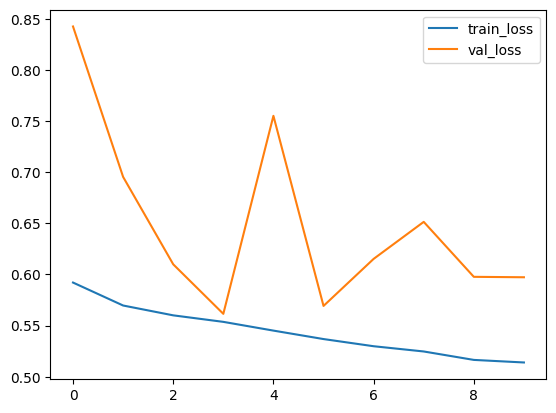

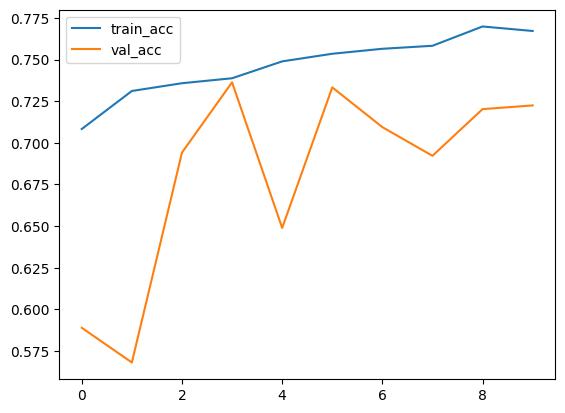

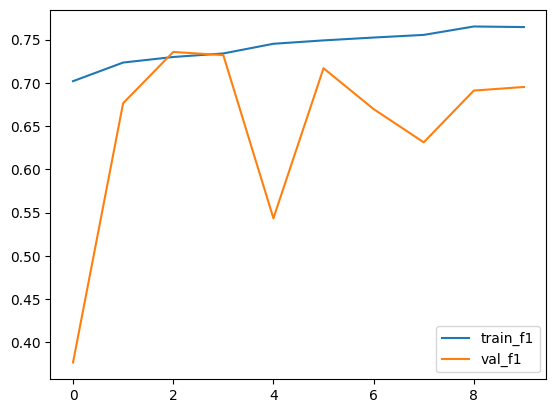

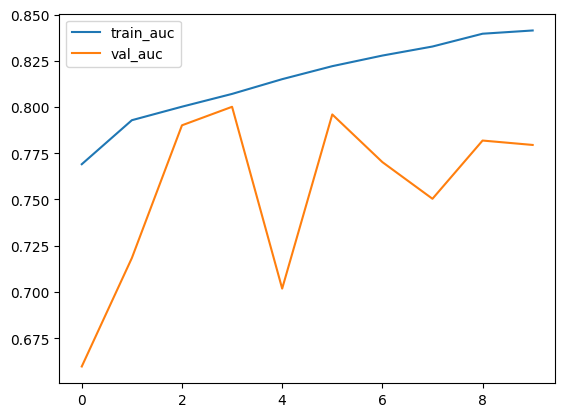

In [26]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_f1"], label="train_f1")
plt.plot(history["val_f1"], label="val_f1")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_auc"], label="train_auc")
plt.plot(history["val_auc"], label="val_auc")
plt.legend()
plt.show()


### Real-time usage

In [27]:
import threading
import time
from collections import defaultdict, deque
from queue import Empty, Full, Queue

from config import FeatureConfig, PoseConfig, RuntimeConfig, TrackConfig
from step1_input import FrameSource
from step2_pose import PoseEstimator
from tracking import Tracker

class GraphConv(nn.Module):
    def __init__(self, in_channels, out_channels, A, stride=1, residual=True, dropout=0.0):
        super().__init__()
        self.A = nn.Parameter(A, requires_grad=False)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=(9, 1), stride=(stride, 1), padding=(4, 0))
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.drop = nn.Dropout(dropout)
        if not residual:
            self.residual = lambda x: 0
        elif in_channels == out_channels and stride == 1:
            self.residual = lambda x: x
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride, 1)),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        res = self.residual(x)
        x = torch.einsum("nctv,vw->nctw", x, self.A)
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.drop(x)
        return x + res


class MultiPersonSTGCN(nn.Module):
    def __init__(self, num_classes=2, in_channels=7, num_persons=3, graph_nodes=None, base_channels=64, dropout=0.5):
        super().__init__()
        if graph_nodes is None:
            graph_nodes = num_persons * 17
        A = build_multi_adjacency(num_persons=num_persons, joints_per_person=graph_nodes // num_persons)
        self.register_buffer("A", A)
        channels = [base_channels, base_channels, base_channels, 2 * base_channels, 2 * base_channels, 4 * base_channels]
        strides = [1, 1, 1, 2, 1, 2]
        layers = []
        c_in = in_channels
        for c_out, s in zip(channels, strides):
            layers.append(GraphConv(c_in, c_out, self.A, stride=s, residual=True, dropout=dropout))
            c_in = c_out
        self.stgcn = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(channels[-1], num_classes)

    def forward(self, x):
        x = self.stgcn(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

def load_classifier(ckpt_path: str | None, device: str):
    if ckpt_path is None:
        return None, {}
    ckpt_path = Path(ckpt_path)
    if not ckpt_path.is_file():
        raise FileNotFoundError(f"Classifier checkpoint not found: {ckpt_path}")
    state = torch.load(ckpt_path, map_location=device)
    metadata = {
        "num_classes": state.get("num_classes", 2),
        "in_channels": state.get("in_channels", 7),
        "graph_nodes": state.get("graph_nodes"),
        "num_persons": state.get("num_persons", 3),
        "base_channels": state.get("base_channels", 64),
        "dropout": state.get("dropout", 0.5),
    }
    model = MultiPersonSTGCN(
        num_classes=metadata["num_classes"],
        in_channels=metadata["in_channels"],
        num_persons=metadata["num_persons"],
        graph_nodes=metadata["graph_nodes"],
        base_channels=metadata["base_channels"],
        dropout=metadata["dropout"],
    ).to(device)
    model.load_state_dict(state["model"])
    model.eval()
    return model, metadata


def _normalize_track(track_seq: list[np.ndarray], frame_shape, seq_len: int) -> np.ndarray:
    """Pad/trim a track and build 7-channel skeleton (coords/vel/acc/conf)."""
    H, W = frame_shape
    seq = list(track_seq)[-seq_len:]
    if len(seq) < seq_len:
        pad_template = np.zeros_like(seq[0]) if seq else np.zeros((17, 3), dtype=np.float32)
        seq = seq + [pad_template.copy() for _ in range(seq_len - len(seq))]
    skeleton = np.stack(seq, axis=0).astype(np.float32)
    skeleton[..., 0] /= max(W, 1e-6)
    skeleton[..., 1] /= max(H, 1e-6)

    coords = skeleton[..., :2]
    conf = skeleton[..., 2:3]

    low_conf_mask = np.repeat(conf < CONF_THRESH, 2, axis=2)
    coords[low_conf_mask] = 0.0

    hip_center = coords[:, [11, 12], :].mean(axis=1, keepdims=True)
    coords -= hip_center

    shoulder = coords[:, [5, 6], :]
    per_frame_len = np.linalg.norm(shoulder[:, 0] - shoulder[:, 1], axis=-1)
    valid = per_frame_len > MIN_SCALE
    scale = float(per_frame_len[valid].mean()) if np.any(valid) else 1.0
    coords /= max(scale, MIN_SCALE)

    radius_mask = np.repeat(np.linalg.norm(coords, axis=-1, keepdims=True) > MAX_RADIUS, 2, axis=2)
    coords[radius_mask] = 0.0

    vel = np.zeros_like(coords)
    vel[1:] = coords[1:] - coords[:-1]
    acc = np.zeros_like(coords)
    acc[2:] = vel[2:] - vel[1:-1]

    skeleton_aug = np.concatenate([coords, vel, acc, conf], axis=-1)  # (T, 17, 7)
    return skeleton_aug


def build_multi_skeleton_tensor(track_histories, seq_len, frame_shape, max_persons, min_len):
    candidates = []
    for tid, hist in track_histories.items():
        if len(hist) < min_len:
            continue
        conf = np.mean([kp[:, 2].mean() for kp in hist])
        candidates.append((len(hist), conf, tid, hist))
    if not candidates:
        return np.zeros((7, seq_len, max_persons * 17), dtype=np.float32)
    candidates.sort(reverse=True)
    selected = candidates[:max_persons]
    tracks_norm = []
    for _, _, _, hist in selected:
        tracks_norm.append(_normalize_track(list(hist), frame_shape, seq_len))
    while len(tracks_norm) < max_persons:
        tracks_norm.append(np.zeros((seq_len, 17, 7), dtype=np.float32))
    stack = np.stack(tracks_norm, axis=0)  # (P, T, 17, 7)
    stack = np.transpose(stack, (0, 3, 1, 2))  # (P, C, T, V)
    stack = stack.transpose(1, 2, 0, 3)  # (C, T, P, V)
    stack = stack.reshape(7, seq_len, max_persons * 17)
    return stack.astype(np.float32, copy=False)


def inference_worker(work_queue: Queue, result_state: dict, lock: threading.Lock, clf: nn.Module, device: str):
    while True:
        item = work_queue.get()
        if item is None:
            work_queue.task_done()
            break
        idx, skeleton = item
        tensor = torch.from_numpy(skeleton).unsqueeze(0).to(device)  # (1, C, T, V)
        with torch.no_grad():
            logits = clf(tensor)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        with lock:
            result_state["window_id"] = idx
            result_state["prob"] = float(probs[1])
        work_queue.task_done()


def detection_worker(frame_queue: Queue, result_queue: Queue, pose: PoseEstimator, tracker: Tracker, max_persons: int):
    while True:
        item = frame_queue.get()
        if item is None:
            frame_queue.task_done()
            break
        frame_idx, frame = item
        detections = pose.infer(frame)
        detections = sorted(detections, key=lambda d: d[1], reverse=True)[:max_persons]
        tracks = tracker.step(detections)
        result_queue.put((frame_idx, tracks, frame.shape[:2]))
        frame_queue.task_done()


def run_async_demo(
    video,
    clf,
    weights="yolov8n-pose.pt",
    device=None,
    seq_len=30,
    stride=15,
    threshold=0.8,
    write_out=None,
    queue_size=4,
    det_queue_size=3,
    max_persons=3,
    show_window=False,
):
    """
    Run the async ST-GCN violence inference demo.

    Parameters are passed directly instead of argparse, so it's easy to call in a Kaggle cell.
    Set show_window=True ONLY on a local machine (not Kaggle).
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Resolve video source
    video_path = video
    if isinstance(video_path, (str, Path)):
        video_path = Path(video_path)
        if not video_path.is_file():
            raise FileNotFoundError(f"Input video not found: {video_path}")
    elif isinstance(video_path, int):
        # Webcam index (works locally, not in Kaggle)
        pass
    else:
        raise ValueError("video must be a filepath (str/Path) or an int webcam index")

    pose_cfg = PoseConfig(weights=weights, device=device)
    track_cfg = TrackConfig()
    feat_cfg = FeatureConfig(seq_len=seq_len, stride=stride)
    run_cfg = RuntimeConfig(alert_threshold=threshold)

    fs = FrameSource(video_path)
    pose = PoseEstimator(
        weights=pose_cfg.weights,
        imgsz=pose_cfg.imgsz,
        conf=pose_cfg.conf,
        iou=pose_cfg.iou,
        device=pose_cfg.device,
        max_det=pose_cfg.max_det,
    )
    tracker = Tracker(
        max_age=track_cfg.max_age,
        min_hits=track_cfg.min_hits,
        iou_threshold=track_cfg.iou_threshold,
    )
    clf_model, metadata = load_classifier(clf, device)
    if clf_model is None:
        raise ValueError("Classifier checkpoint must be provided for async demo.")

    fps = fs.cap.get(cv2.CAP_PROP_FPS) or 30.0
    out_writer = None
    if write_out:
        out_path = Path(write_out)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        cap = fs.cap
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        out_writer = cv2.VideoWriter(str(out_path), fourcc, fps, (width, height))

    work_queue: Queue = Queue(maxsize=queue_size)
    result_state = {"prob": 0.0, "window_id": -1}
    state_lock = threading.Lock()
    worker = threading.Thread(
        target=inference_worker,
        args=(work_queue, result_state, state_lock, clf_model, device),
        daemon=True,
    )
    worker.start()

    frame_queue: Queue = Queue(maxsize=det_queue_size)
    result_queue: Queue = Queue(maxsize=det_queue_size * 2)
    det_thread = threading.Thread(
        target=detection_worker,
        args=(frame_queue, result_queue, pose, tracker, max_persons),
        daemon=True,
    )
    det_thread.start()

    prob_text = "Violence prob: --"
    last_prob = 0.0
    last_display = None
    track_histories: dict[int, deque] = defaultdict(lambda: deque(maxlen=feat_cfg.seq_len))
    track_last_seen: dict[int, int] = {}
    frame_idx = 0
    processed_idx = 0
    last_infer_idx = -1
    window_counter = 0
    min_len = max(4, feat_cfg.seq_len // 2)
    latest_tracks = []
    frame_shape = None

    try:
        while True:
            ok, frame = fs.read()
            if not ok:
                break
            frame_idx += 1
            try:
                frame_queue.put_nowait((frame_idx, frame.copy()))
            except Full:
                pass

            while True:
                try:
                    proc_idx, tracks, det_shape = result_queue.get_nowait()
                except Empty:
                    break
                frame_shape = det_shape
                processed_idx = proc_idx
                for tid, bbox, keypoints in tracks:
                    track_histories[tid].append(keypoints.copy())
                    track_last_seen[tid] = proc_idx
                stale_ids = [tid for tid, last_seen in track_last_seen.items() if proc_idx - last_seen > feat_cfg.seq_len]
                for tid in stale_ids:
                    track_histories.pop(tid, None)
                    track_last_seen.pop(tid, None)

                latest_tracks = tracks

                if (
                    frame_shape is not None
                    and not work_queue.full()
                    and proc_idx >= min_len
                    and (proc_idx - min_len) % feat_cfg.stride == 0
                    and proc_idx != last_infer_idx
                ):
                    skeleton = build_multi_skeleton_tensor(
                        track_histories,
                        feat_cfg.seq_len,
                        frame_shape,
                        max_persons=max_persons,
                        min_len=min_len,
                    )
                    work_queue.put((window_counter, skeleton))
                    window_counter += 1
                    last_infer_idx = proc_idx

            with state_lock:
                if result_state["window_id"] >= 0:
                    last_prob = result_state["prob"]
                    prob_text = f"Violence prob: {last_prob:.2f}"

            now = time.perf_counter()
            if last_display is not None:
                elapsed = now - last_display
                if fps > 0:
                    target_period = 1.0 / fps
                    if elapsed < target_period:
                        time.sleep(target_period - elapsed)
                        now = time.perf_counter()
                fps_text = f"FPS: {1.0/elapsed:.1f}" if elapsed > 0 else "FPS: --"
            else:
                fps_text = "FPS: --"
            last_display = now

            color = (0, 0, 255) if last_prob >= run_cfg.alert_threshold else (0, 255, 0)
            cv2.putText(frame, prob_text, (12, 32), cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)
            cv2.putText(frame, fps_text, (12, 64), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

            for tid, bbox, keypoints in latest_tracks:
                x1, y1, x2, y2 = bbox.astype(int)
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                for x, y, conf in keypoints:
                    if conf > 0.1:
                        cv2.circle(frame, (int(x), int(y)), 2, (255, 0, 0), -1)
                cv2.putText(frame, f"ID {tid}", (x1, y1 - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

            # Local real-time display 
            if show_window:
                cv2.imshow("Async Violence Demo (Multi-person)", frame)
                if cv2.waitKey(1) & 0xFF == ord("q"):
                    break

            # Always safe on Kaggle: write to video if enabled
            if out_writer is not None:
                out_writer.write(frame)

    finally:
        frame_queue.put(None)
        work_queue.put(None)
        det_thread.join()
        worker.join()
        if out_writer is not None:
            out_writer.release()
        fs.release()
        if show_window:
            cv2.destroyAllWindows()


In [40]:
video_path = "/kaggle/input/rwf2000/RWF-2000/train/Fight/_2RYnSFPD_U_0.avi" # you can use any video from rwf2000
clf_ckpt = "/kaggle/working/checkpoints/best_model.pth"
pose_weights = "/kaggle/working/yolov8n-pose.pt"

out_path = "/kaggle/working/out.mp4"

run_async_demo(
    video=video_path,
    clf=clf_ckpt,
    weights=pose_weights,
    device="cuda",  
    seq_len=30,
    stride=15,
    threshold=0.8,
    write_out=out_path,
    queue_size=4,
    det_queue_size=3,
    max_persons=3,
    show_window=False    
)

In [42]:
# re-encode the video to a browser-friendly H.264 MP4 with ffmpeg, but you can run out.mp4 without errors if you download locally
!ffmpeg -y -i /kaggle/working/out.mp4 -vcodec libx264 -acodec aac /kaggle/working/out_fixed.mp4


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [43]:
from IPython.display import Video

Video("/kaggle/working/out_fixed.mp4", embed=True)
